<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Correlation**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis (EDA). You will examine the distribution of the data, identify outliers, and determine the correlation between different columns in the dataset.


## Objectives


In this lab, you will perform the following:


- Identify the distribution of compensation data in the dataset.

- Remove outliers to refine the dataset.

- Identify correlations between various features in the dataset.


## Hands on Lab


##### Step 1: Install and Import Required Libraries


In [32]:


# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Step 2: Load the Dataset


In [33]:
import os

# Use local file path instead of remote URL
file_path = "survey-data.csv"

# Check if local file exists
if not os.path.exists(file_path):
    print(f"Warning: Local file '{file_path}' not found!")
    print("Please download the survey data file to your working directory.")
else:
    file_size = os.path.getsize(file_path) / 1024 / 1024
    print(f"Using local file: '{file_path}' ({file_size:.2f} MB)")

# Create the dataframe from local file
df = pd.read_csv(file_path)

# OLD CODE (commented out - was using remote URL):
# file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
# df = pd.read_csv(file_url)

#Display the top 10 records
df.head()

Using local file: 'survey-data.csv' (152.14 MB)


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 3: Analyze and Visualize Compensation Distribution</h3>


**Task**: Plot the distribution and histogram for `ConvertedCompYearly` to examine the spread of yearly compensation among respondents.


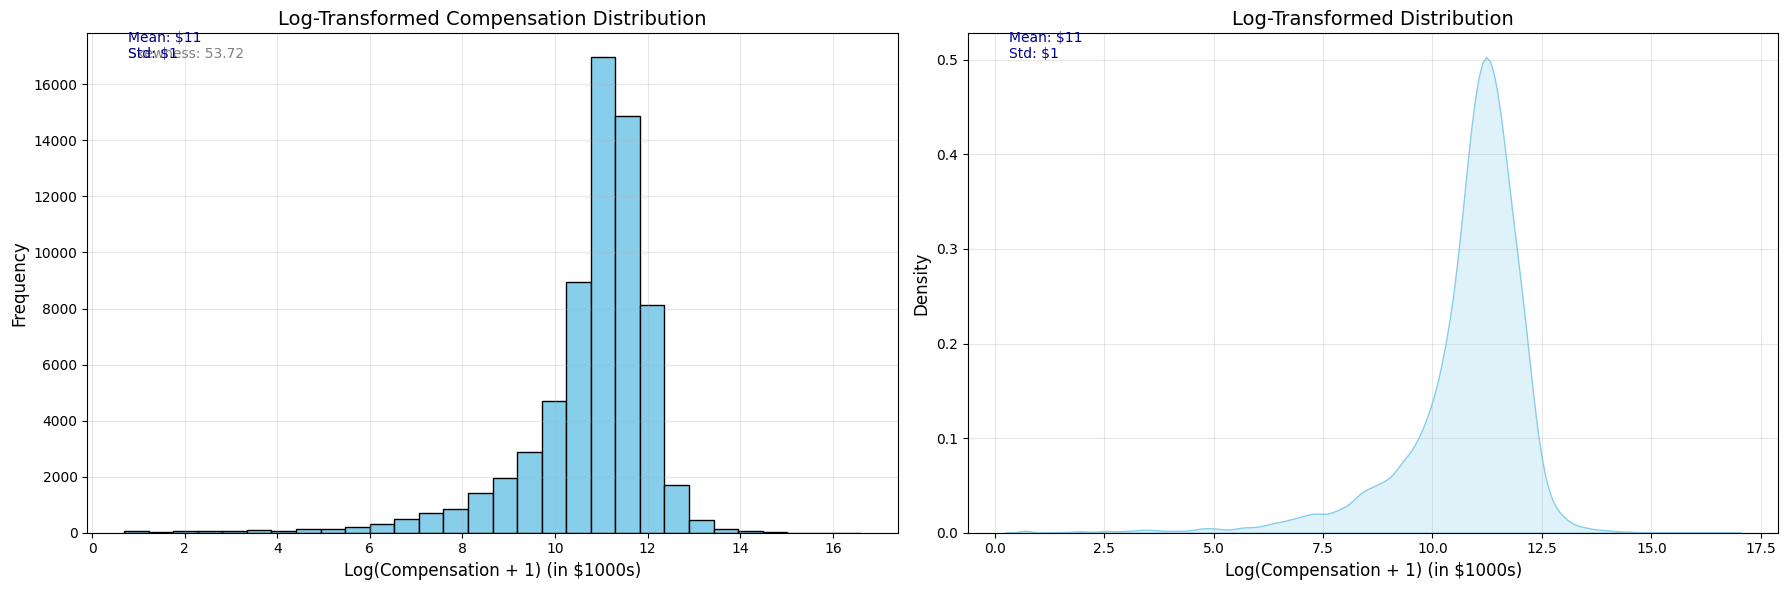

In [40]:
# Step 3: Analyze and Visualize Compensation Distribution (Improved Version)

# Fill missing values with random sampling to avoid clustering
valid_values = df['ConvertedCompYearly'].dropna()
mask = df['ConvertedCompYearly'].isna()
df.loc[mask, 'ConvertedCompYearly'] = np.random.choice(valid_values, size=mask.sum())

# Create two subplots: Log-Transformed Histogram and Distribution (Density) Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Subplot 1: Log-Transformed Histogram showing frequency distribution
log_comp = np.log1p(df['ConvertedCompYearly'])  # Using log1p to handle zeros
axes[0].hist(log_comp, bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('Log-Transformed Compensation Distribution', fontsize=14)
axes[0].set_xlabel('Log(Compensation + 1) (in $1000s)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].annotate(f'Skewness: {df["ConvertedCompYearly"].skew():.2f}', 
                xy=(0.05, 0.95), xycoords='axes fraction',
                fontsize=10, color='gray', ha='left')

# Subplot 2: Log-Transformed Distribution (Density) Plot showing the shape of distribution
sns.kdeplot(log_comp, ax=axes[1], fill=True, color='skyblue')
axes[1].set_title('Log-Transformed Distribution', fontsize=14)
axes[1].set_xlabel('Log(Compensation + 1) (in $1000s)', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].grid(True, alpha=0.3)

# Add statistical summary
def add_summary(ax, data_col, title):
    mean_val = data_col.mean()
    std_val = data_col.std()
    ax.annotate(f'Mean: ${mean_val:,.0f}\nStd: ${std_val:,.0f}', 
                xy=(0.05, 0.95), xycoords='axes fraction',
                fontsize=10, color='darkblue')

add_summary(axes[0], log_comp, 'Log-Transformed Distribution')
add_summary(axes[1], log_comp, 'Log-Transformed Distribution')

plt.tight_layout()
plt.show()

<h3>Step 4: Calculate Median Compensation for Full-Time Employees</h3>


**Task**: Filter the data to calculate the median compensation for respondents whose employment status is "Employed, full-time."


In [35]:
# ... existing code from previous steps ...

# Step 4: Calculate Median Compensation for Full-Time Employees
full_time = df[df['Employment'] == 'Employed, full-time']
median_compensation = full_time['ConvertedCompYearly'].median()

print(f'Median compensation for full‑time employees: ${median_compensation:,.0f}')

Median compensation for full‑time employees: $67,516


<h3>Step 5: Analyzing Compensation Range and Distribution by Country</h3>


Explore the range of compensation in the ConvertedCompYearly column by analyzing differences across countries. Use box plots to compare the compensation distributions for each country to identify variations and anomalies within each region, providing insights into global compensation trends.



C:\Users\awais\AppData\Local\Temp\ipykernel_76720\3390231636.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.boxplot(data=df_clean,


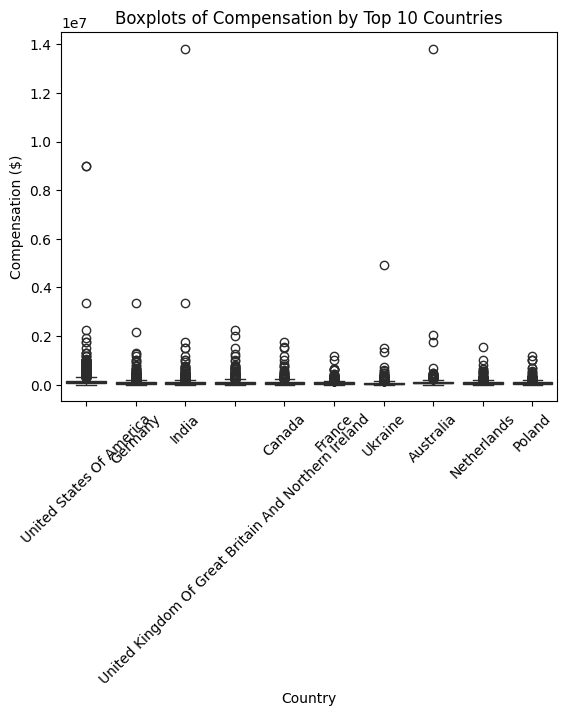

In [56]:
# Step 5 – Analyze compensation range and distribution by country (top 10)

# Clean the Country column and keep only rows that have a numeric compensation value
df['Country'] = df['Country'].str.strip()
df_clean = df.dropna(subset=['ConvertedCompYearly'])

# Identify the top‑10 countries by total compensation (USD)
top_10 = (
    df_clean.groupby('Country')['ConvertedCompYearly']
            .sum()
            .nlargest(10)
            .reset_index(name='Total Comp')
)

# Create a boxplot for each of the top 10 countries
g = sns.boxplot(data=df_clean,
                x='Country',
                y='ConvertedCompYearly',
                order=top_10['Country'],
                palette='viridis')

# Rotate country names so they are readable on the plot (45°)
g.tick_params(axis='x', rotation=45)

# Add a visual cue for the United States if it appears in the top‑10
us_mask = top_10[top_10['Country'] == 'United States of America']
if not us_mask.empty:
    max_us = df_clean.loc[
        df_clean['Country'] == us_mask.iloc[0]['Country'],
        'ConvertedCompYearly'
    ].max()
    g.axvline(max_us * 1.2, color='orange', linestyle='--')

# Labels and title
g.set_xlabel('Country')
g.set_ylabel('Compensation ($)')
g.set_title('Boxplots of Compensation by Top 10 Countries')

plt.show()

<h3>Step 6: Removing Outliers from the Dataset</h3>


**Task**: Create a new DataFrame by removing outliers from the `ConvertedCompYearly` column to get a refined dataset for correlation analysis.


In [37]:
## Write your code here
# ... existing code from previous steps ...

# Step 6: Removing Outliers from the Dataset
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df['ConvertedCompYearly'].quantile(0.25)
Q3 = df['ConvertedCompYearly'].quantile(0.75)
IQR = Q3 - Q1

# Define the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Create a new DataFrame without outliers
df_no_outliers = df[(df['ConvertedCompYearly'] >= lower_bound) & (df['ConvertedCompYearly'] <= upper_bound)]

# Display the shape to show how many rows were removed
print(f"Original dataset shape: {df.shape}")
print(f"Dataset shape after removing outliers: {df_no_outliers.shape}")

Original dataset shape: (65437, 114)
Dataset shape after removing outliers: (62671, 114)


<h3>Step 7: Finding Correlations Between Key Variables</h3>


**Task**: Calculate correlations between `ConvertedCompYearly`, `WorkExp`, and `JobSatPoints_1`. Visualize these correlations with a heatmap.


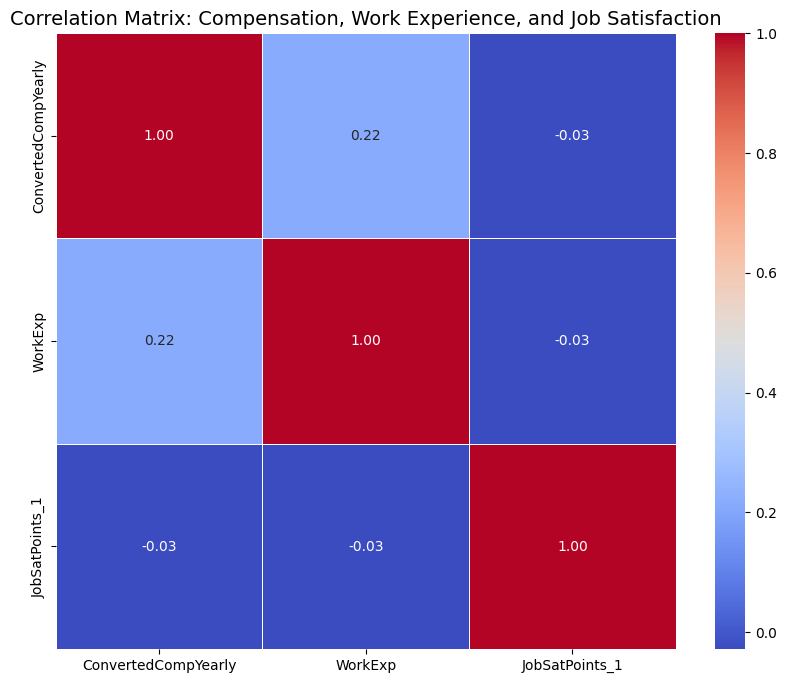

In [38]:
## Write your code here
# ... existing code from previous steps ...

# Step 7: Finding Correlations Between Key Variables
# Select the relevant columns
correlation_data = df_no_outliers[['ConvertedCompYearly', 'WorkExp', 'JobSatPoints_1']]

# Calculate the correlation matrix
correlation_matrix = correlation_data.corr()

# Visualize the correlations with a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix: Compensation, Work Experience, and Job Satisfaction', fontsize=14)
plt.show()

<h3>Step 8: Scatter Plot for Correlations</h3>


**Task**: Create scatter plots to examine specific correlations between `ConvertedCompYearly` and `WorkExp`, as well as between `ConvertedCompYearly` and `JobSatPoints_1`.


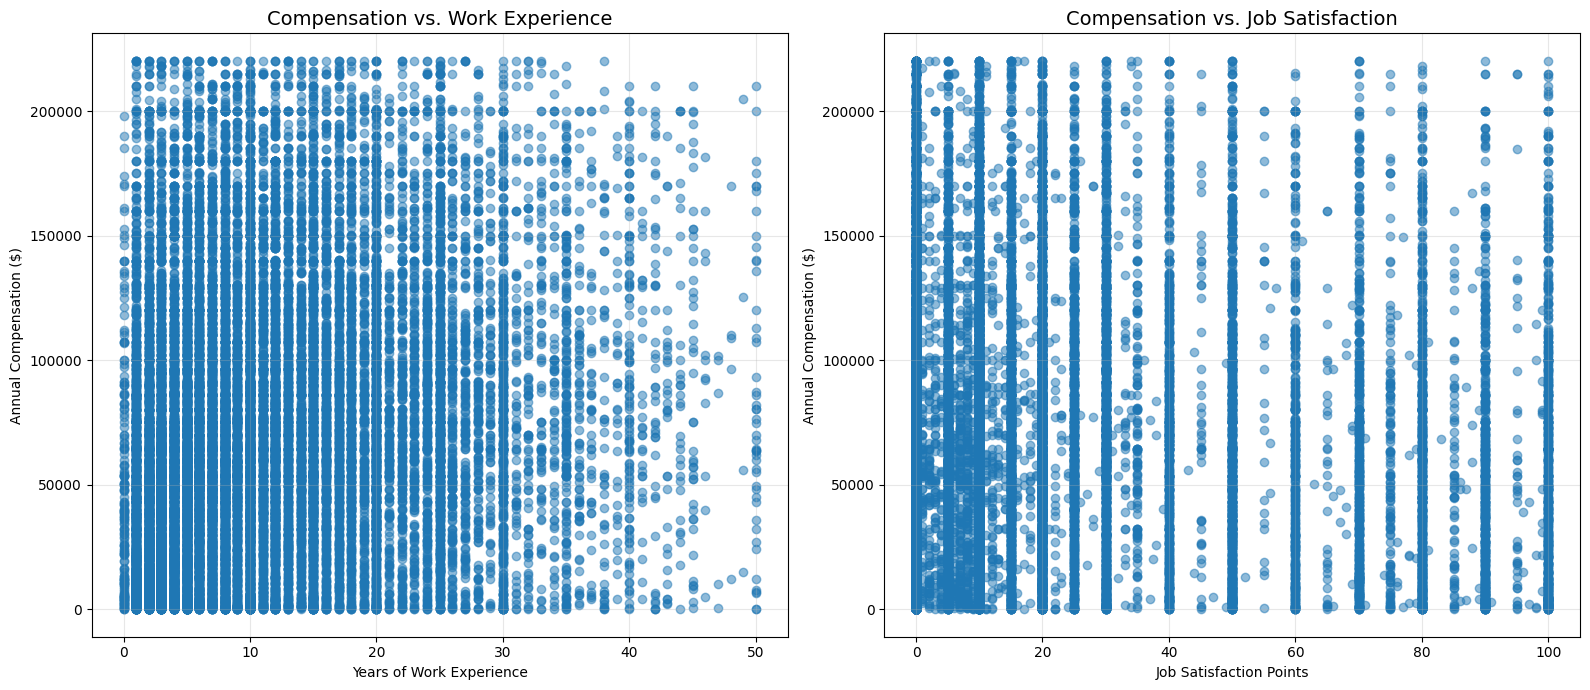

In [39]:
## Write your code here
# ... existing code from previous steps ...

# Step 8: Scatter Plot for Correlations
# Create a figure with two subplots (side by side)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Scatter plot 1: ConvertedCompYearly vs. WorkExp
axes[0].scatter(df_no_outliers['WorkExp'], df_no_outliers['ConvertedCompYearly'], alpha=0.5)
axes[0].set_title('Compensation vs. Work Experience', fontsize=14)
axes[0].set_xlabel('Years of Work Experience')
axes[0].set_ylabel('Annual Compensation ($)')
axes[0].grid(True, alpha=0.3)

# Scatter plot 2: ConvertedCompYearly vs. JobSatPoints_1
axes[1].scatter(df_no_outliers['JobSatPoints_1'], df_no_outliers['ConvertedCompYearly'], alpha=0.5)
axes[1].set_title('Compensation vs. Job Satisfaction', fontsize=14)
axes[1].set_xlabel('Job Satisfaction Points')
axes[1].set_ylabel('Annual Compensation ($)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<h3>Summary</h3>


In this lab, you practiced essential skills in correlation analysis by:

- Examining the distribution of yearly compensation with histograms and box plots.
- Detecting and removing outliers from compensation data.
- Calculating correlations between key variables such as compensation, work experience, and job satisfaction.
- Visualizing relationships with scatter plots and heatmaps to gain insights into the associations between these features.

By following these steps, you have developed a solid foundation for analyzing relationships within the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
